In [1]:
import requests
import os
from dotenv import load_dotenv
from pprint import pprint
import pandas as pd
import json

# .env 파일에서 환경 변수 로드
load_dotenv()

# 환경 변수에서 값 읽기
client_id = os.getenv("CLIENT_ID")  # .env 파일의 NAVER_CLIENT_ID
client_secret = os.getenv("CLIENT_SECRET")  # .env 파일의 NAVER_CLIENT_SECRET
print(client_id[:4])
print(client_secret[:4])

headers = {
    'X-NCP-APIGW-API-KEY-ID': client_id,
    'X-NCP-APIGW-API-KEY': client_secret,
}

ic0k
An89


In [3]:

def search_local(query, display=100): 
    # query string 문자열을 dict 선언
    payload = {
        'query': query,
        'display': display,
        'sort': 'sim'
    }

    DOMAIN_URL = 'https://naverapihub.apigw.ntruss.com'

    url = f'{DOMAIN_URL}/search/v1/news'
    print(url)

    # requests get(url, params, headers) 요청 
    res = requests.get(url, params=payload, headers=headers)
    # json() 함수로 응답 결과 가져오기
    items_data = res.json()['items']
    print(len(items_data))
    
    return items_data  #[{},{}]

def save_json(items_data):
    with open('../data/news.json','w',encoding='utf-8') as file:
        json.dump(items_data, file)


if __name__ == '__main__':
    save_json(search_local('부동산', display=100))

https://naverapihub.apigw.ntruss.com/search/v1/news
100


In [4]:
import time

def search_news_all(query, total=500, display=100):
    DOMAIN_URL = 'https://naverapihub.apigw.ntruss.com'
    url = f'{DOMAIN_URL}/search/v1/news'
    all_items = []

    for start in range(1, total + 1, display):   # 1, 101, 201, 301, 401
        payload = {
            'query': query,
            'display': display,
            'start': start,
            'sort': 'sim'
        }
        res = requests.get(url, params=payload, headers=headers)
        data = res.json()

        items = data.get('items', [])
        if not items:          # 더 이상 결과가 없으면 중단
            break
        all_items.extend(items)

        time.sleep(0.1)        # 호출 간 간격 (API 부하/제한 대비)

    return all_items          # 최대 500개


if __name__ == '__main__':
    items = search_news_all('부동산', total=500, display=100)
    print(len(items))
    save_json(items)

500


In [5]:
import pandas as pd

news_df = pd.read_json('../data/news.json')
print(len(news_df))
news_df.head(2)

500


,title,originallink,link,description,pubDate
0,‘<b>부동산</b> 민심’ 달래는 與… “주거 사다리 복원할 것”,https://biz.chosun.com/policy/politics/assembl...,https://n.news.naver.com/mnews/article/366/000...,“이달 중 9·7 대책 후속 법안 처리할 것” 더불어민주당이 정부의 <b>부동산</...,"Wed, 12 Aug 2026 15:31:00 +0900"
1,<b>부동산</b> '세제 개편안' 꼬인 세 가지 이유,https://www.ohmynews.com/NWS_Web/View/at_pg.as...,https://n.news.naver.com/mnews/article/047/000...,▲ 지난 4일 서울 강남구 공인중개사에 <b>부동산</b> 매물이 게시되어 있다....,"Thu, 13 Aug 2026 06:56:00 +0900"


```
pip install pandas konlpy matplotlib wordcloud scikit-learn networkx
```
| 라이브러리 | import 이름 | 용도 |
|---|---|---|
| `pandas` | `pandas` | 데이터프레임(news_df) 처리 |
| `konlpy` | `konlpy` | 한글 형태소 분석(명사 추출), konlpy는 별도로 Java JDK 설치도 필요 |
| `matplotlib` | `matplotlib` | 그래프 그리기 |
| `wordcloud` | `wordcloud` | 워드클라우드 생성 |
| `scikit-learn` | `sklearn` | TF-IDF 계산 (설치명과 import명이 다름 주의) |
| `networkx` | `networkx` | 연관어 네트워크 그래프 |


##### TF-IDF란?
* **Term Frequency–Inverse Document Frequency (단어 빈도–역문서 빈도)**
* 여러 문서 중에서 **이 단어가 특정 문서에서 얼마나 중요한가**를 수치화 하는 기법.

##### 두 요소의 곱
* **TF (단어 빈도)**: 한 문서 안에서 그 단어가 자주 나올수록 ↑
* **IDF (역문서 빈도)**: 여러 문서에 흔하게 나오는 단어일수록 ↓ (희귀할수록 ↑)
* `TF-IDF = TF × IDF`

##### 핵심 아이디어
* **이 문서엔 자주 나오지만, 다른 문서엔 잘 안 나오는 단어**에 높은 점수.
* '정부', '부동산'처럼 모든 기사에 나오는 흔한 단어 → 점수 낮음
* '연금', '양도소득세'처럼 그 기사에만 두드러진 단어 → 점수 높음

#### 왜 유용한가
* 단순 빈도는 어느 문서든 흔한 단어가 1등이라 구별이 안 됨.
* TF-IDF는 흔한 단어를 눌러줘서 **각 문서만의 특징어**가 드러남.
    * → 검색 순위, 문서 분류, 키워드 추출, 문서 유사도 계산에 활용.

## 형태소 분석이란?

**형태소(morpheme)**: 의미를 가진 가장 작은 말의 단위.
**형태소 분석**: 문장을 형태소 단위로 쪼개고, 각 형태소의 품사(명사·동사·조사 등)를 판별하는 것.

예) "부동산 정책을 발표했다"
→ 부동산(명사) / 정책(명사) / 을(조사) / 발표(명사) / 하(동사) / 였(어미) / 다(어미)

### 왜 필요한가 (특히 한국어)
- 한국어는 **띄어쓰기만으로 단어를 못 나눔** ("정책을", "정책은", "정책이"가 다 다른 덩어리)
- 조사·어미가 붙어 변형되므로, **의미 단위인 명사·동사만 추출**하려면 형태소 분석이 필수
- 키워드 분석에서 조사·어미 같은 불필요한 요소를 걸러내는 핵심 전처리

### KoNLPy란
한국어 형태소 분석을 파이썬에서 쉽게 쓰게 해주는 **라이브러리**.
내부에 여러 분석기(엔진)를 포함하며, 상황에 맞게 골라 씀.

| 분석기 | 특징 |
|---|---|
| **Okt** | 빠르고 가벼움, 구어체·SNS에 강함 (가장 많이 씀) |
| **Kkma** | 정밀하지만 느림 |
| **Komoran** | 오탈자·신조어에 비교적 강함 |
| **Hannanum / Mecab** | Mecab은 속도가 매우 빠름 (설치 까다로움) |

### 자주 쓰는 기능 (Okt 기준)
```python
from konlpy.tag import Okt
okt = Okt()

okt.nouns("부동산 정책을 발표했다")   # 명사만 → ['부동산', '정책', '발표']
okt.morphs("부동산 정책을 발표했다")  # 형태소 전체 → ['부동산','정책','을','발표','했다']
okt.pos("부동산 정책을 발표했다")     # (형태소, 품사) 쌍 → [('부동산','Noun'),('을','Josa')...]
```

> ※ KoNLPy는 내부적으로 Java로 동작 → 실행하려면 **JDK 설치**가 필요.

In [1]:
! java --version

openjdk 17.0.2 2022-01-18
OpenJDK Runtime Environment (build 17.0.2+8-86)
OpenJDK 64-Bit Server VM (build 17.0.2+8-86, mixed mode, sharing)


In [3]:
! pip install konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 


In [7]:
# 설치 안되어있을 시 
# ! pip install wordcloud
! pip show wordcloud

Name: wordcloud
Version: 1.9.6
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: 
Author-email: Andreas Mueller <t3kcit+wordcloud@gmail.com>
License: 
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: matplotlib, numpy, pillow
Required-by: 


In [8]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.5.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn


In [9]:
!pip show networkx

Name: networkx
Version: 3.3
Summary: Python package for creating and manipulating graphs and networks
Home-page: https://networkx.org/
Author: 
Author-email: Aric Hagberg <hagberg@lanl.gov>
License: 
Location: C:\Users\user\anaconda3\Lib\site-packages
Requires: 
Required-by: intake, scikit-image


In [11]:
import pandas as pd
import re                    # (내장) 정규표현식 - HTML 태그 제거용
import itertools             # (내장) 조합(combinations) - 단어 쌍 만들기용
from collections import Counter   # (내장) 항목 개수 세기
from konlpy.tag import Okt        # 한글 형태소 분석기 (명사 추출)
import matplotlib.pyplot as plt   # 그래프 그리기
from matplotlib import font_manager as fm   # 폰트 등록/관리
from wordcloud import WordCloud             # 워드클라우드
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 계산
import networkx as nx        # 네트워크(그래프) 시각화

In [12]:
# ─────────────────────────────────────────────────────────────
# 한글 폰트 설정 (Windows 맑은고딕 Bold)
#   - matplotlib은 기본 폰트에 한글이 없어 지정하지 않으면 글자가 깨짐
# ─────────────────────────────────────────────────────────────
FONT = 'C:\\Windows\\Fonts\\malgunbd.ttf'          # 폰트 '파일 경로'
fm.fontManager.addfont(FONT)                        # matplotlib에 이 폰트를 등록
FONT_NAME = fm.FontProperties(fname=FONT).get_name()   # 등록된 폰트의 '이름'을 얻음 → 'Malgun Gothic'
plt.rcParams['font.family'] = FONT_NAME             # matplotlib 기본 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False          # 음수(-) 기호가 깨지는 문제 방지

In [13]:
# ─────────────────────────────────────────────────────────────
# 0. 데이터 로드
#   - search_local()로 저장해 둔 news.json을 데이터프레임으로 읽음
# ─────────────────────────────────────────────────────────────
news_df = pd.read_json('../data/news.json')
print(len(news_df))          # 읽어온 기사 개수 확인

500


In [ ]:
news_df.head(10)['title']

In [ ]:
news_df.head(5)[['title','description']]

In [18]:
# ─────────────────────────────────────────────────────────────
# 전처리 함수: 기사 본문에 섞인 HTML 태그/특수문자를 제거
#   - 네이버 API 응답에는 검색어가 <b>부동산</b> 처럼 태그로 감싸여 옴
#   - &quot; 같은 HTML 엔티티도 실제 문자로 되돌려야 분석이 깨끗해짐
#   - 이 처리를 안 하면 'b', 'quot' 같은 쓰레기 단어가 상위 키워드로 잡힘
# ─────────────────────────────────────────────────────────────
def clean(t):
    t = re.sub(r'<[^>]+>', '', str(t))              # <...> 형태의 모든 태그 삭제
    for a, b in [('&quot;', '"'), ('&amp;', '&'), ('&lt;', '<'),
                 ('&gt;', '>'), ('&nbsp;', ' '), ('&apos;', "'")]:
        t = t.replace(a, b)                         # HTML 엔티티 → 원래 문자로 복원
    return re.sub(r'\s+', ' ', t).strip()           # 여러 개의 공백을 하나로 정리

# title과 description을 합쳐 분석 대상 텍스트(text) 컬럼 생성
news_df['text'] = news_df['title'].map(clean) + ' ' + news_df['description'].map(clean)


In [19]:
news_df['text'].head(2)

0    ‘부동산 민심’ 달래는 與… “주거 사다리 복원할 것” “이달 중 9·7 대책 후속...
1    부동산 '세제 개편안' 꼬인 세 가지 이유 ▲ 지난 4일 서울 강남구 공인중개사에 ...
Name: text, dtype: object

In [23]:
# ─────────────────────────────────────────────────────────────
# 1. 명사 추출
#   - 형태소 분석기로 명사만 골라냄 (조사·동사 등은 키워드로 부적합)
#   - 한 글자 단어와 불용어(의미 없는 단어), 검색어 자체는 제거
# ─────────────────────────────────────────────────────────────
okt = Okt()   # 형태소 분석기 객체 생성

# 불용어 집합: 자주 나오지만 분석에 의미 없는 단어들 + 검색어 '부동산'
#   → 결과를 보면서 계속 추가해 나가면 결과가 깔끔해짐
stop = {'부동산', '기자', '뉴스', '때문', '관련', '이날', '우리', '최근', '오늘',
        '대한', '통해', '위해', '이번', '정도', '자신', '모든', '경우', '기사'}

def nouns(t):
    # okt.nouns(): 문장에서 명사만 리스트로 추출
    # 조건: 2글자 이상 그리고 불용어가 아닌 것만 남김
    return [w for w in okt.nouns(t) if len(w) >= 2 and w not in stop]

news_df['nouns'] = news_df['text'].map(nouns)        # 기사별 명사 리스트 컬럼 추가
news_df['nouns'].head() # ['명사1', '명사2'] lst 반복문 500줄
len(news_df)


500

In [22]:

# 모든 기사의 명사를 하나의 리스트로 펼침 (이중 for문: 리스트 안의 리스트 평탄화)
all_nouns = [w for lst in news_df['nouns'] for w in lst]
len(all_nouns)

13105

In [ ]:

cnt = Counter(all_nouns)     # 단어별 등장 횟수 계산 → {'정부': 68, '정책': 68, ...}
cnt

In [ ]:
# [('정부', 304), ('정책', 287),]
cnt.most_common(20)     # 제일 많은 단어 TOP 20

In [41]:
zip(*cnt.most_common(20))
# 아래와 똑같은 의미:
# zip(('정부', 68), ('정책', 68), ('주택', 50), ('민주당', 39), ...)
for val in zip(*cnt.most_common(20)):
    print(val)      # *없을때 (('정부', 304),)(('정책', 287),)
                    # *있을때 ('정부', '정책',)(304, 287,)

('정부', '정책', '공급', '주택', '개편안', '대책', '세제', '민주당', '대통령', '회의', '시장', '점검', '이재명', '의원', '국민', '개발', '지지율', '문제', '발표', '논의')
(304, 287, 284, 214, 190, 176, 174, 166, 159, 151, 148, 116, 100, 99, 94, 90, 86, 81, 79, 77)


In [42]:

words, vals = zip(*cnt.most_common(20))
print(words)
print(vals)


('정부', '정책', '공급', '주택', '개편안', '대책', '세제', '민주당', '대통령', '회의', '시장', '점검', '이재명', '의원', '국민', '개발', '지지율', '문제', '발표', '논의')
(304, 287, 284, 214, 190, 176, 174, 166, 159, 151, 148, 116, 100, 99, 94, 90, 86, 81, 79, 77)


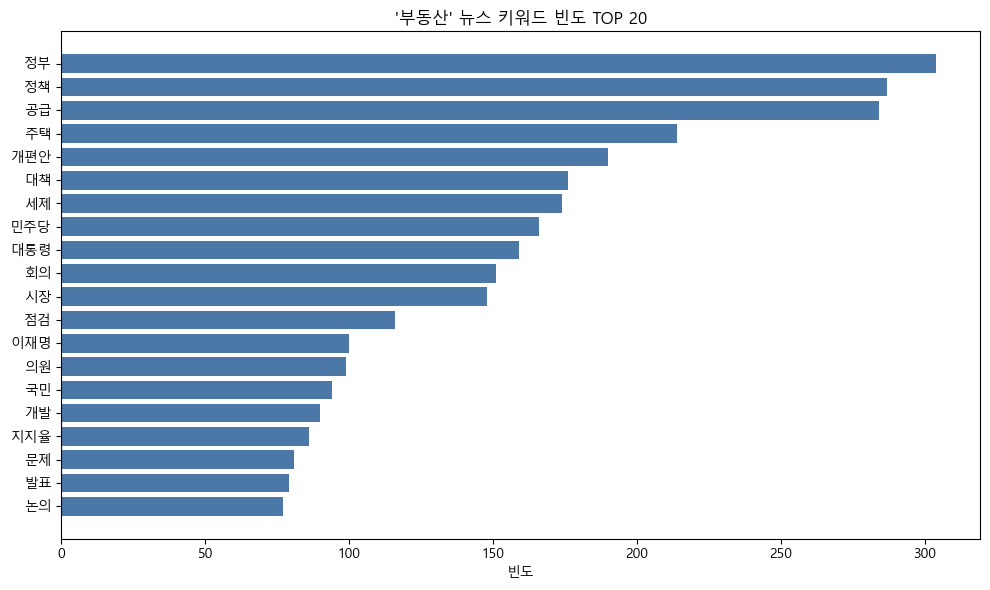

In [27]:
# ─────────────────────────────────────────────────────────────
# [분석1] 키워드 빈도 막대그래프
#   - 가장 많이 나온 단어 20개를 가로 막대그래프로 표시
# ─────────────────────────────────────────────────────────────
words, vals = zip(*cnt.most_common(20))   # 빈도 상위 20개를 (단어들), (빈도들)로 분리
plt.figure(figsize=(10, 6))
# barh: 가로 막대. reversed()로 순서를 뒤집어 1위가 맨 위에 오게 함
plt.barh(list(reversed(words)), list(reversed(vals)), color='#4C78A8')
#plt.barh(list(words), list(vals), color='#4C78A8')
plt.title("'부동산' 뉴스 키워드 빈도 TOP 20")
plt.xlabel('빈도')
plt.tight_layout()                        # 라벨이 잘리지 않게 여백 자동 조정
plt.savefig('freq.png', dpi=120)          # 이미지 파일로 저장
plt.show()


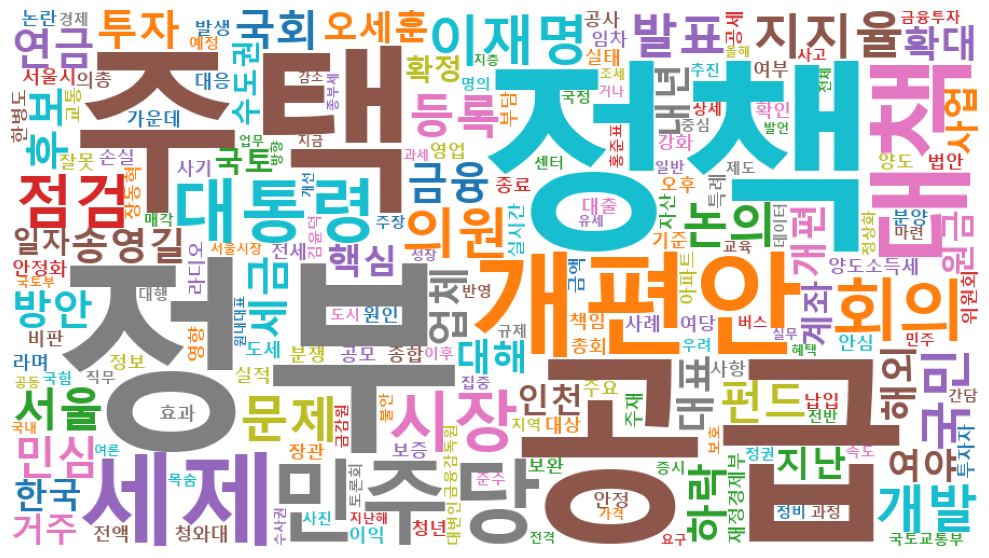

In [ ]:
# ─────────────────────────────────────────────────────────────
# [분석2] 워드클라우드
#   - 단어 빈도가 높을수록 크게 그려주는 시각화
#   - 주의: WordCloud는 폰트 '이름'이 아니라 '파일 경로'(font_path)를 받음
# ─────────────────────────────────────────────────────────────
wc = WordCloud(font_path=FONT,            # 한글 폰트 파일 경로
               background_color='white',
               width=900, height=500,
               colormap='tab10'           # 색상 팔레트
               ).generate_from_frequencies(cnt)   # 빈도 딕셔너리로 생성, cnt: 단어별 횟수 값
plt.figure(figsize=(10, 6))
plt.imshow(wc)      # 워드클라우드 이미지 표시
plt.axis('off')     # 축 눈금 숨김
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=120)
plt.show()

노드 수: 13 / 엣지 수: 48


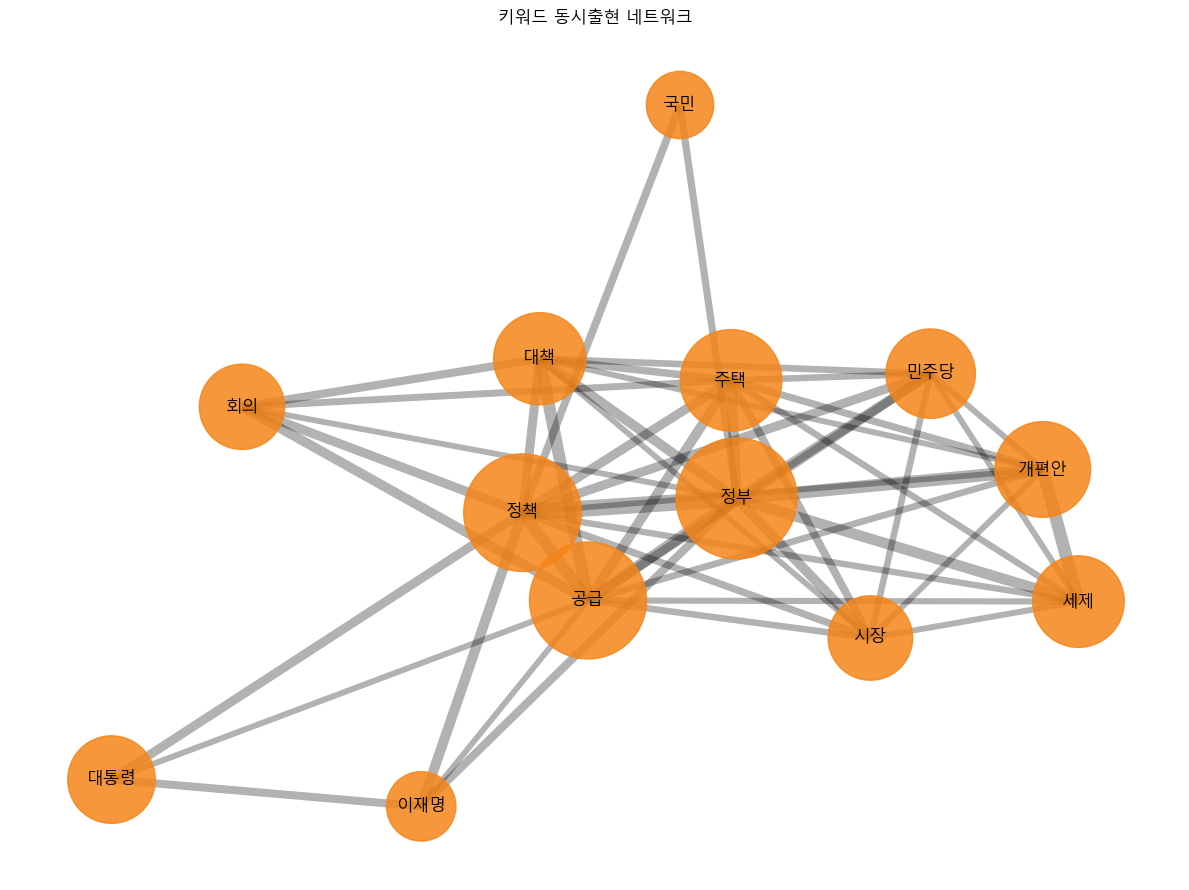

In [29]:
# ─────────────────────────────────────────────────────────────
# [분석3] 연관어(동시출현) 네트워크
#   - '같은 기사에 함께 등장한' 단어 쌍을 세어 관계망으로 그림
#   - 자주 함께 나오는 단어일수록 굵은 선으로 연결됨
#   — 500건 데이터 인 경우에
#     - 데이터가 많을수록 NODE_MIN / EDGE_MIN 을 올려 노드 수를 줄인다
#     - 목표: 노드 30~50개 (print로 확인하며 조절)
# ─────────────────────────────────────────────────────────────

# ── 데이터 양에 맞춰 이 세 숫자만 조절하면 됩니다 ──
NODE_MIN  = 60   # 노드로 쓸 단어의 최소 빈도 (데이터 많을수록 ↑)
EDGE_MIN  = 40   # 선으로 연결할 최소 동시출현 (데이터 많을수록 ↑)
LABEL_TOP = 60   # 라벨(글자)을 달 상위 단어 개수 (노드 수와 비슷하게)

# 1) 같은 기사에 함께 등장한 단어 쌍 세기
pair = Counter()
for lst in news_df['nouns']:
    # 한 기사 안에서 빈도 NODE_MIN 이상인 단어만 골라 중복 제거
    uniq = sorted(set(w for w in lst if cnt[w] >= NODE_MIN))
    for a, b in itertools.combinations(uniq, 2):
        pair[(a, b)] += 1

# 2) EDGE_MIN 이상 함께 등장한 쌍만 선(edge)으로 연결
G = nx.Graph()
for (a, b), c in pair.items():
    if c >= EDGE_MIN:
        G.add_edge(a, b, weight=c)

# 3) 연결이 거의 없는 고립 노드(선 1개 이하) 제거
G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) < 2])

# 4) 노드/엣지 개수 확인 → 이 값을 보며 위 두 숫자를 조절
print("노드 수:", G.number_of_nodes(), "/ 엣지 수:", G.number_of_edges())

# 5) 그리기
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=1.2, seed=42)          # k ↑ → 노드 간격 넓어짐

# 노드: 단어 빈도가 클수록 크게
nx.draw_networkx_nodes(G, pos, node_color='#F58518',
                       node_size=[cnt[n] * 25 for n in G.nodes()], alpha=.85)
# 엣지: 동시출현이 많을수록 굵게
nx.draw_networkx_edges(G, pos, alpha=.3,
                       width=[G[u][v]['weight'] * .1 for u, v in G.edges()])

# 라벨: 빈도 상위 LABEL_TOP개 단어에만 표시 (글자 겹침 방지)
big = [n for n, _ in sorted(((n, cnt[n]) for n in G.nodes()),
                            key=lambda x: -x[1])[:LABEL_TOP]]
nx.draw_networkx_labels(G, pos, labels={n: n for n in big}, font_family=FONT_NAME)

plt.title('키워드 동시출현 네트워크')
plt.axis('off')
plt.tight_layout()
plt.savefig('network.png', dpi=120)
plt.show()

In [30]:
# ─────────────────────────────────────────────────────────────
# [분석4] TF-IDF 기사별 핵심어
#   - TF-IDF: 특정 기사에는 자주 나오지만 다른 기사엔 드문 단어에 높은 점수
#   - 단순 빈도와 달리 '그 기사만의 특징어'를 뽑아줌
# ─────────────────────────────────────────────────────────────
# 각 기사의 명사 리스트를 공백으로 이어붙여 하나의 문자열(문서)로 만듦
docs = [' '.join(lst) for lst in news_df['nouns']]

# TfidfVectorizer: 문서들을 TF-IDF 수치 행렬로 변환
#   token_pattern: 한 글자 단어도 토큰으로 인정하도록 패턴 지정
tv = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
M = tv.fit_transform(docs)              # M: (기사 수 × 단어 수) 크기의 TF-IDF 행렬
vocab = tv.get_feature_names_out()      # 열 인덱스에 해당하는 실제 단어 목록

# 앞에서부터 5개 기사에 대해 핵심어 상위 5개씩 출력
for i in range(10):
    row = M[i].toarray()[0]             # i번째 기사의 TF-IDF 점수 배열
    top = row.argsort()[::-1][:5]       # 점수가 높은 순으로 인덱스 정렬 후 상위 5개
    # 점수가 0보다 큰 단어만 '단어(점수)' 형태로 조합
    kw = ', '.join(f"{vocab[j]}({row[j]:.2f})" for j in top if row[j] > 0)
    print(f"[기사{i+1}] {clean(news_df['title'][i])[:30]}\n   핵심어: {kw}")

[기사1] ‘부동산 민심’ 달래는 與… “주거 사다리 복원할 것”
   핵심어: 민심(0.31), 조직(0.30), 사다리(0.30), 전담(0.30), 복원(0.30)
[기사2] 부동산 '세제 개편안' 꼬인 세 가지 이유
   핵심어: 세제(0.33), 중개사(0.29), 공인(0.29), 관심(0.27), 배경(0.26)
[기사3] 정청래 “LH 정상화” 김민석 “재정 더 투입” 송영길
   핵심어: 후보(0.24), 탈당(0.23), 투입(0.23), 지방선거(0.23), 불교(0.23)
[기사4] 송영길 “이 대통령 지지율 하락, 부동산 잘못 다뤄 발
   핵심어: 잘못(0.43), 발생(0.41), 문제(0.33), 가구(0.25), 지적(0.24)
[기사5] '연일 내리막' 대통령 지지율, 왜?... "부동산 탓
   핵심어: 후보(0.37), 코어(0.33), 당청(0.23), 일치(0.23), 탈론(0.23)
[기사6] 민주당 부동산 의총, 선상반란 일어날까[오늘의 여의도]
   핵심어: 총회(0.45), 민주당(0.35), 의원(0.33), 지역구(0.23), 선상(0.23)
[기사7] 부동산 수세 몰린 與, 오세훈에 역공…“31만호 실제 
   핵심어: 오세훈(0.37), 역공(0.33), 대규모(0.31), 실제(0.29), 연일(0.27)
[기사8] 부동산 팔고 연금 납입 시 양도세 감면 혜택, 내년 말
   핵심어: 연금(0.48), 납입(0.33), 계좌(0.32), 양도소득세(0.31), 내년(0.30)
[기사9] 송영길 "지지율 하락 핵심은 부동산…정청래 진단은 돌팔
   핵심어: 핵심(0.28), 송영길(0.28), 후보(0.28), 하락(0.27), 지지율(0.26)
[기사10] 민주당, 오늘 세제 개편안·부동산 대책 논의⋯비거주 1
   핵심어: 방안(0.33), 대해(0.31), 논의(0.31), 교환(0.27), 형평성(0.27)
